# EDA đầy đủ — thị trường tuyển dụng IT trên ITviec (29/09/2026)

14 biểu đồ chất lượng trình bày (font ≥ 12pt, có tiêu đề, nhãn trục, chú thích nguồn). Mỗi hình được lưu vào `reports/figures/eda_<tên>.png` để dùng cho slide. Hàm vẽ nằm ở `src/viz/eda.py` (cũng chạy được bằng `python scripts/run_pipeline.py figures`).

Các con số đi kèm đều **in ra từ code** bên dưới mỗi hình — slide lấy số từ đây hoặc từ `final_notebook.ipynb`.

**Dữ liệu cần có:** `data/processed/jobs_clean.parquet` và `data/processed/skill_matrix.parquet` (tải từ Drive, hoặc chạy `python scripts/run_pipeline.py skills`). Hash phải khớp `docs/MANIFEST.json`.

Notebook chỉ hiển thị số liệu tổng hợp, **không** in nguyên văn JD (cam kết ToS, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Chạy được dù mở notebook từ thư mục gốc repo hay từ notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, load_data, save_figure, salary_tertiles, skill_share

# load_data() kiểm SHA-256 của jobs_clean + skill_matrix với docs/MANIFEST.json, lệch thì dừng
jobs, skills = load_data()
print(f"{len(jobs)} tin, {skills.shape[1]} kỹ năng — hash khớp docs/MANIFEST.json")

688 tin, 100 kỹ năng — hash khớp docs/MANIFEST.json


## 1. Dữ liệu qua pipeline

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_pipeline_funnel.png')

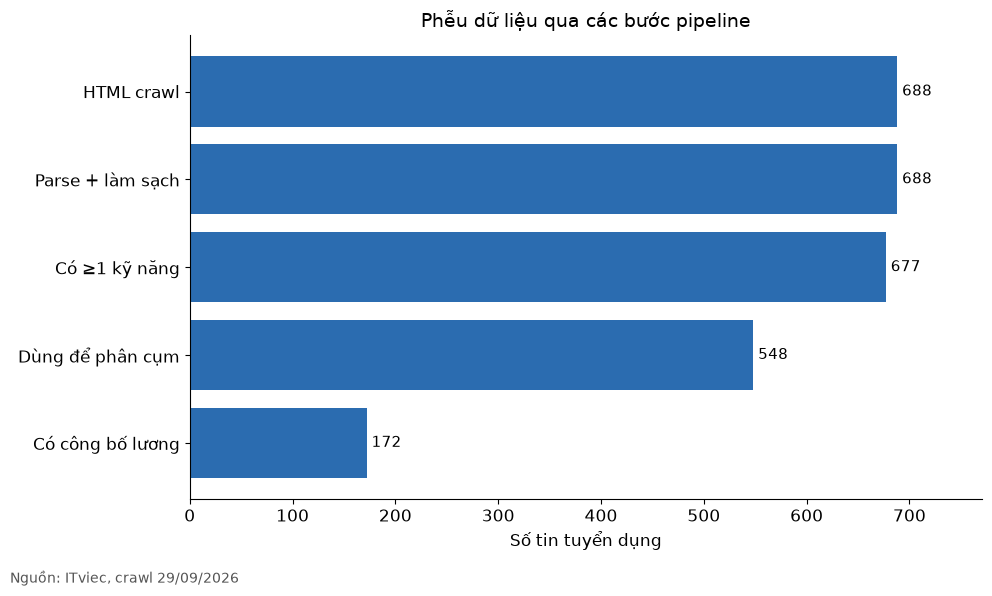

In [2]:
fig = FIGURES["pipeline_funnel"](jobs, skills)
save_figure(fig, "pipeline_funnel")  # → reports/figures/eda_pipeline_funnel.png

## 2. Lương

Lương lấy từ JSON-LD `baseSalary` (giao diện ITviec ẩn lương sau đăng nhập — DECISIONS 29/09), quy về triệu VND/tháng (tỷ giá 25.780 VND/USD — A9; không điều chỉnh gross/net — A14).

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_disclosure.png')

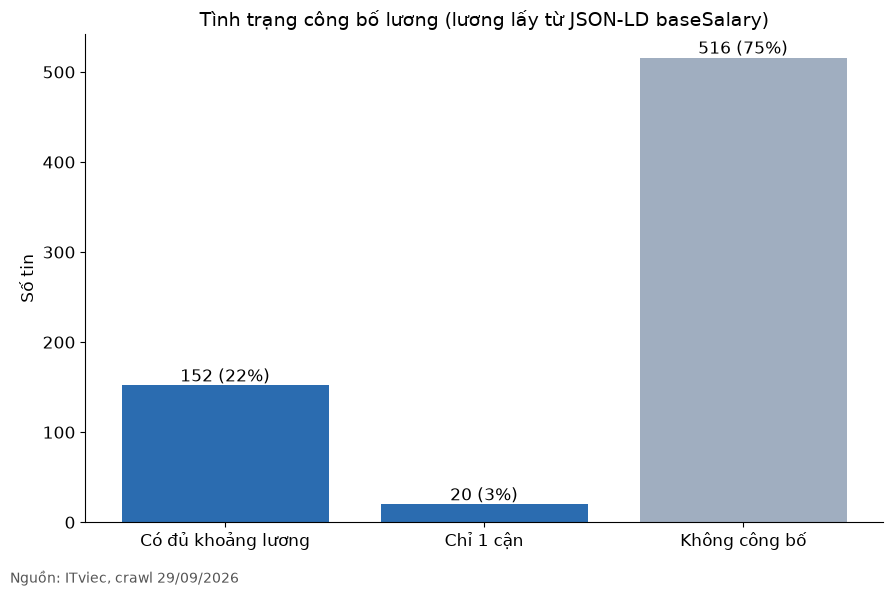

In [3]:
fig = FIGURES["salary_disclosure"](jobs, skills)
save_figure(fig, "salary_disclosure")  # → reports/figures/eda_salary_disclosure.png

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_distribution.png')

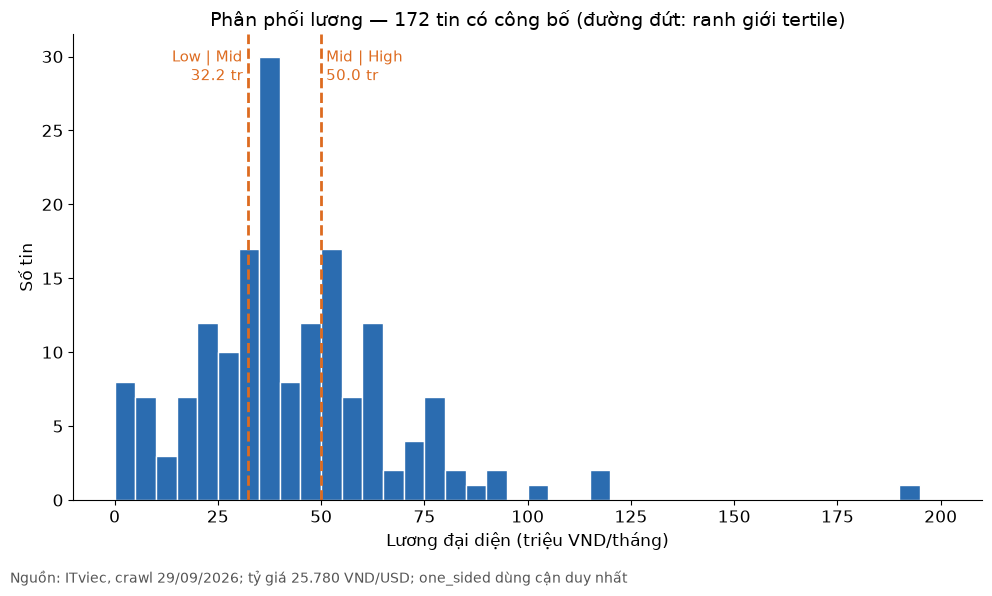

In [4]:
fig = FIGURES["salary_distribution"](jobs, skills)
save_figure(fig, "salary_distribution")  # → reports/figures/eda_salary_distribution.png

In [5]:
paid = jobs.loc[jobs["has_salary"], "salary_mid"]
_, (low, high) = salary_tertiles(jobs)
print(f"Tin có lương: {len(paid)}/{len(jobs)} ({len(paid)/len(jobs):.1%})")
print(f"Trung vị {paid.median():.1f} tr | Q1 {paid.quantile(.25):.1f} | Q3 {paid.quantile(.75):.1f} | max {paid.max():.1f}")
print(f"Ranh giới tertile: Low < {low:.1f} ≤ Mid < {high:.1f} ≤ High (triệu VND/tháng)")

Tin có lương: 172/688 (25.0%)
Trung vị 38.7 tr | Q1 28.4 | Q3 51.6 | max 193.4
Ranh giới tertile: Low < 32.2 ≤ Mid < 50.0 ≤ High (triệu VND/tháng)


PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_currency.png')

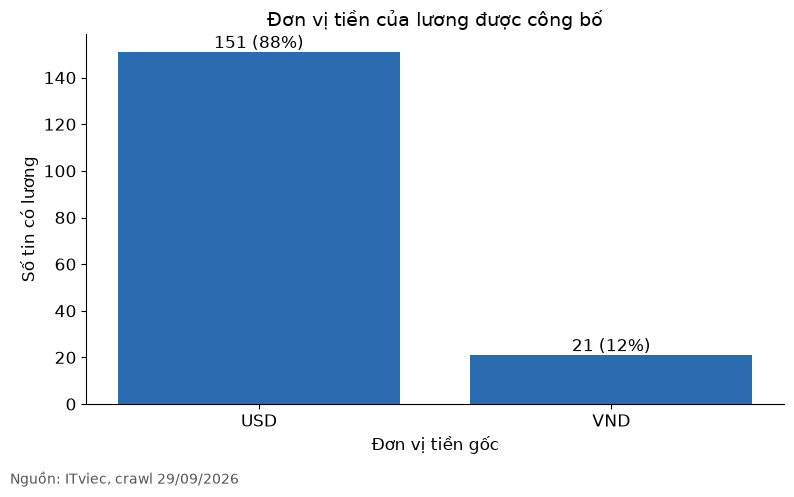

In [6]:
fig = FIGURES["currency"](jobs, skills)
save_figure(fig, "currency")  # → reports/figures/eda_currency.png

## 3. Kỹ năng

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_top_skills.png')

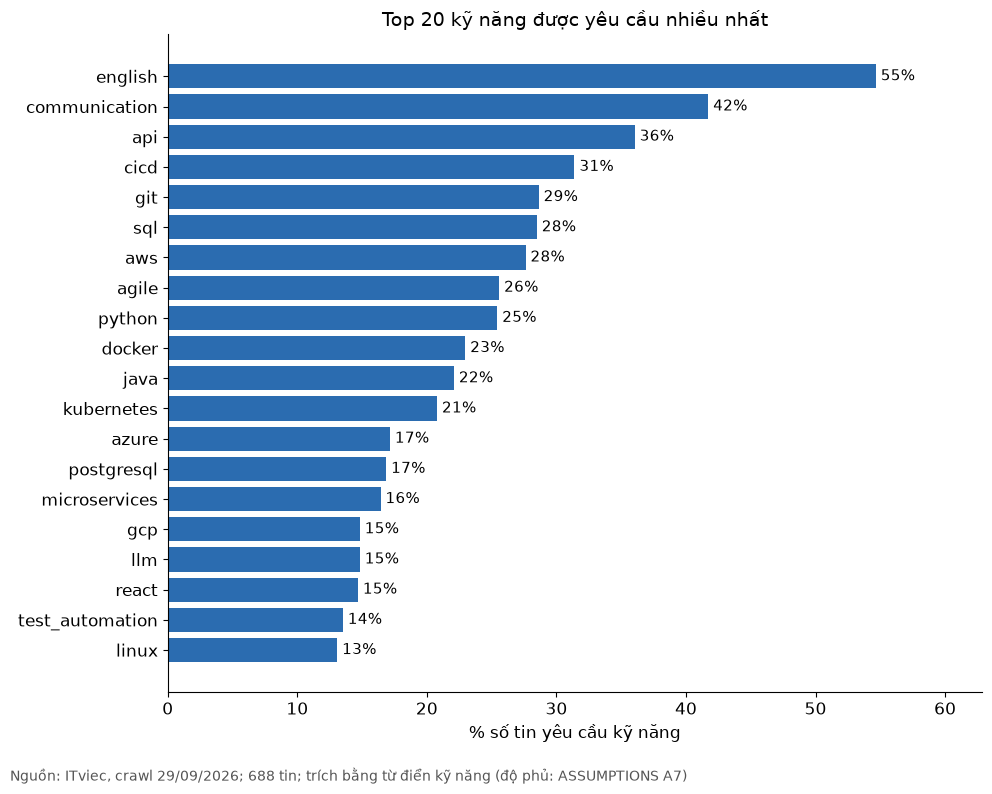

In [7]:
fig = FIGURES["top_skills"](jobs, skills)
save_figure(fig, "top_skills")  # → reports/figures/eda_top_skills.png

In [8]:
share = skill_share(skills)
print("Top 10 kỹ năng (% số tin):")
print((share.head(10) * 100).round(1).to_string())

Top 10 kỹ năng (% số tin):
english          54.7
communication    41.7
api              36.0
cicd             31.4
git              28.6
sql              28.5
aws              27.6
agile            25.6
python           25.4
docker           23.0


PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_skills_per_job.png')

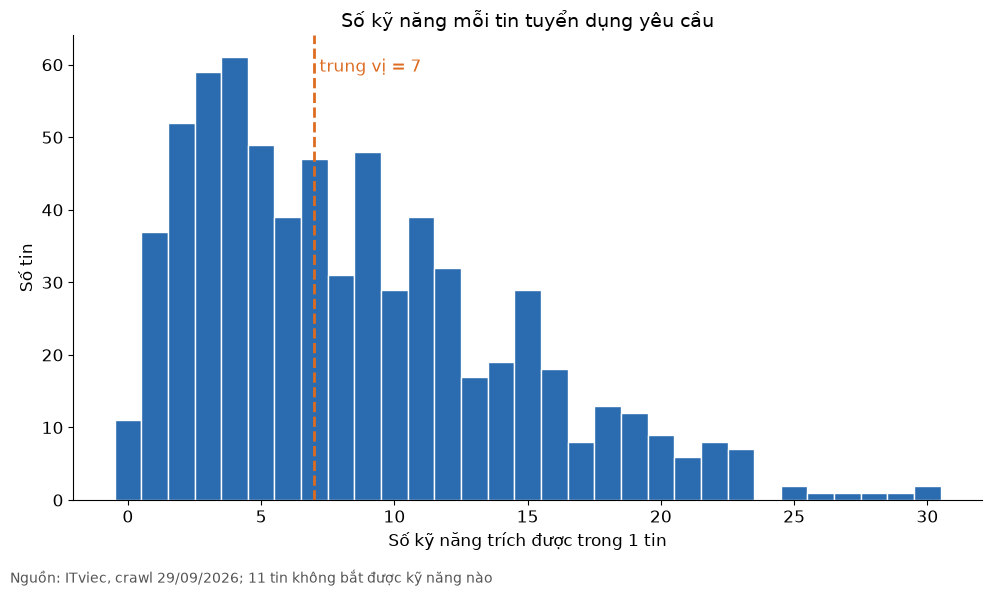

In [9]:
fig = FIGURES["skills_per_job"](jobs, skills)
save_figure(fig, "skills_per_job")  # → reports/figures/eda_skills_per_job.png

Ma trận lift cho biết cặp kỹ năng nào hay xuất hiện cùng nhau hơn mức ngẫu nhiên (lift > 1) — gợi ý trước cho phần luật kết hợp (Apriori) trong `final_notebook.ipynb`.

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_cooccurrence.png')

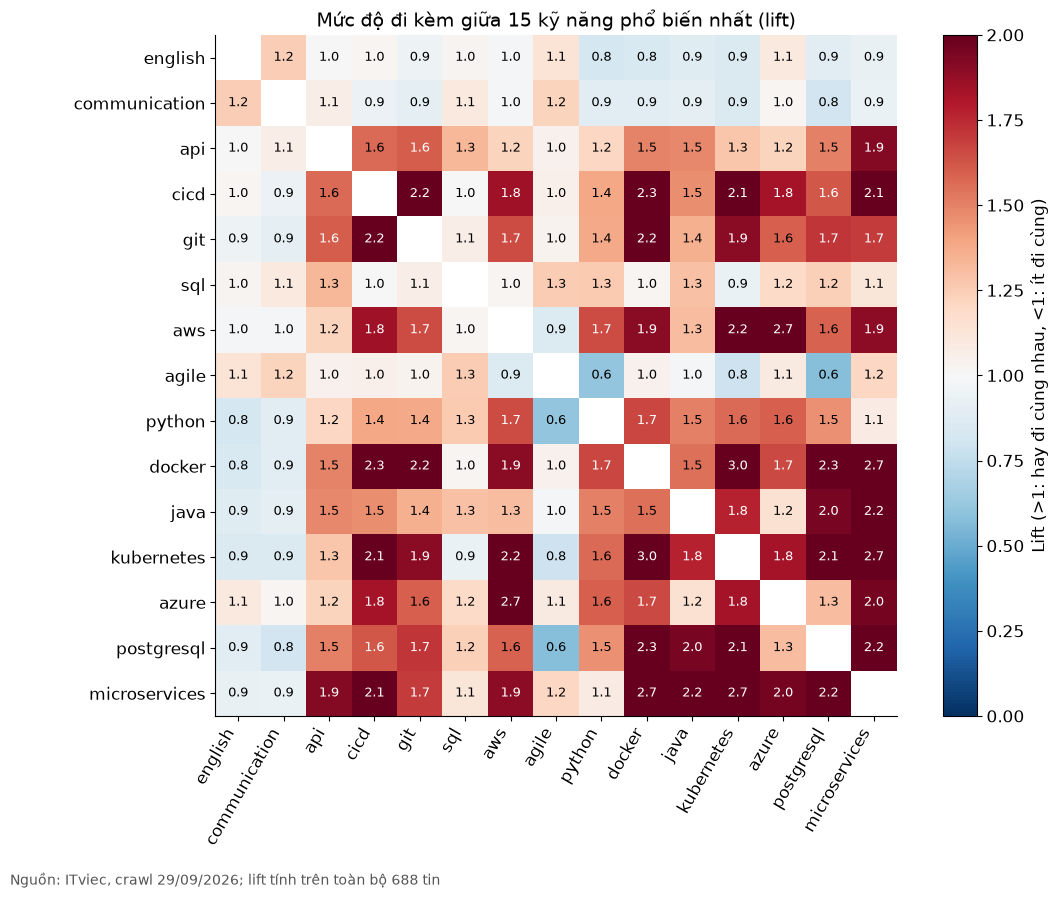

In [10]:
fig = FIGURES["cooccurrence"](jobs, skills)
save_figure(fig, "cooccurrence")  # → reports/figures/eda_cooccurrence.png

## 4. Địa điểm và cấp bậc

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_locations.png')

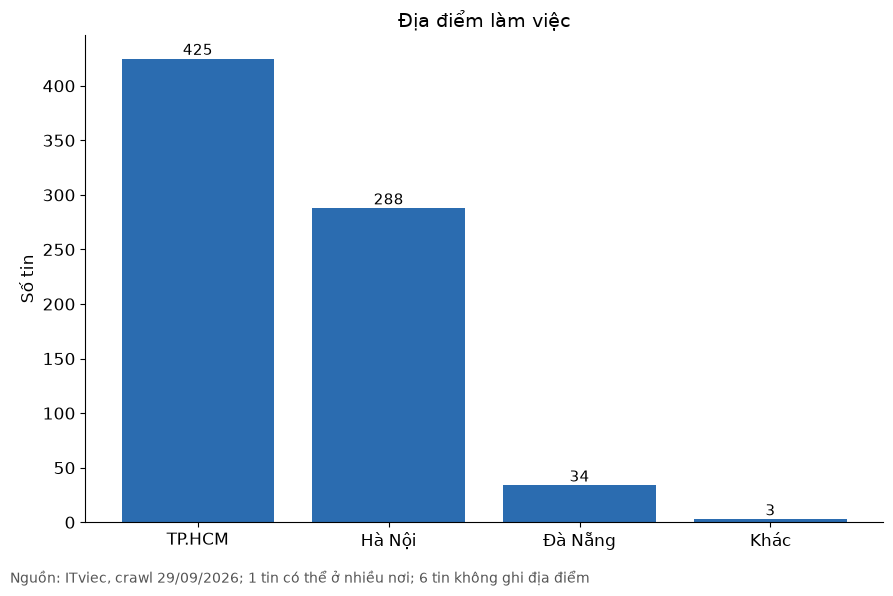

In [11]:
fig = FIGURES["locations"](jobs, skills)
save_figure(fig, "locations")  # → reports/figures/eda_locations.png

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_levels.png')

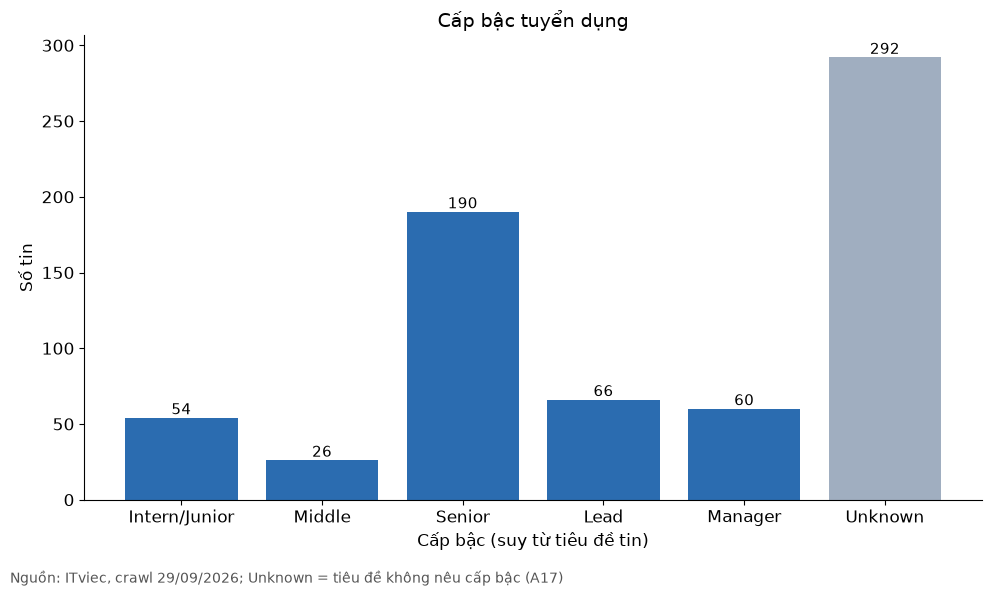

In [12]:
fig = FIGURES["levels"](jobs, skills)
save_figure(fig, "levels")  # → reports/figures/eda_levels.png

In [13]:
print(jobs["level_group"].value_counts().to_string())
print(f"\nKhông suy được cấp bậc từ tiêu đề: {(jobs['level_group'] == 'Unknown').mean():.1%}")

level_group
Unknown          292
Senior           190
Lead              66
Manager           60
Intern/Junior     54
Middle            26

Không suy được cấp bậc từ tiêu đề: 42.4%


## 5. Lương theo cấp bậc và địa điểm

⚠️ Nhóm `Intern/Junior` có lương chủ yếu là thực tập sinh (phụ cấp, không phải lương) — xem `reports/classification_report.md`.

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_by_level.png')

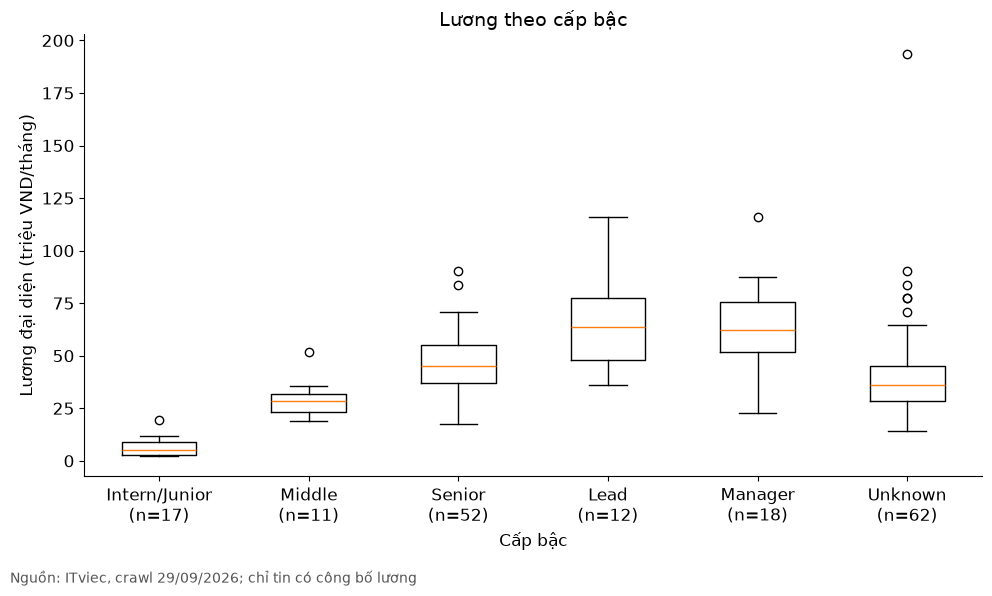

In [14]:
fig = FIGURES["salary_by_level"](jobs, skills)
save_figure(fig, "salary_by_level")  # → reports/figures/eda_salary_by_level.png

In [15]:
print(jobs[jobs["has_salary"]].groupby("level_group")["salary_mid"].agg(["count", "median"]).round(1).to_string())

               count  median
level_group                 
Intern/Junior     17     5.2
Lead              12    63.8
Manager           18    62.2
Middle            11    28.4
Senior            52    45.1
Unknown           62    36.1


PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_by_location.png')

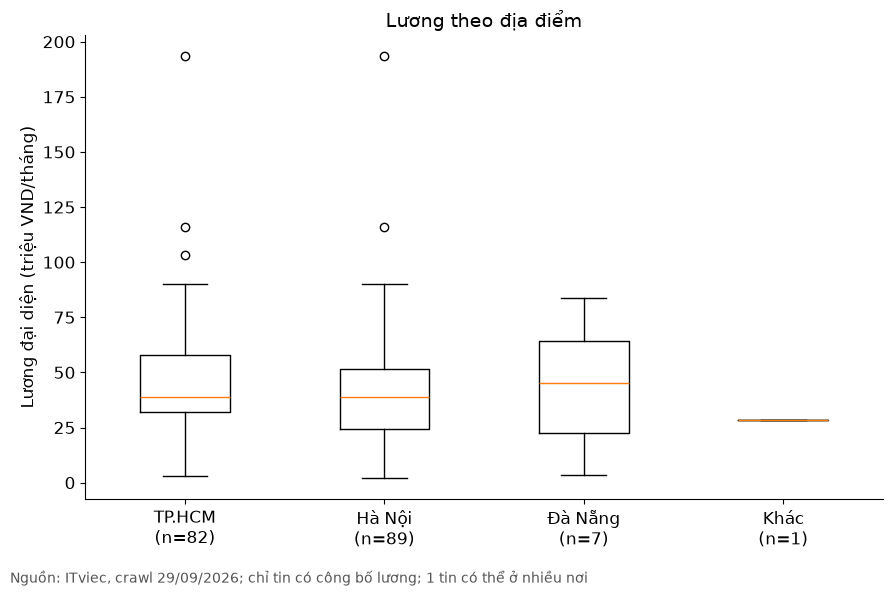

In [16]:
fig = FIGURES["salary_by_location"](jobs, skills)
save_figure(fig, "salary_by_location")  # → reports/figures/eda_salary_by_location.png

## 6. Nhóm nghề

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_expertise_groups.png')

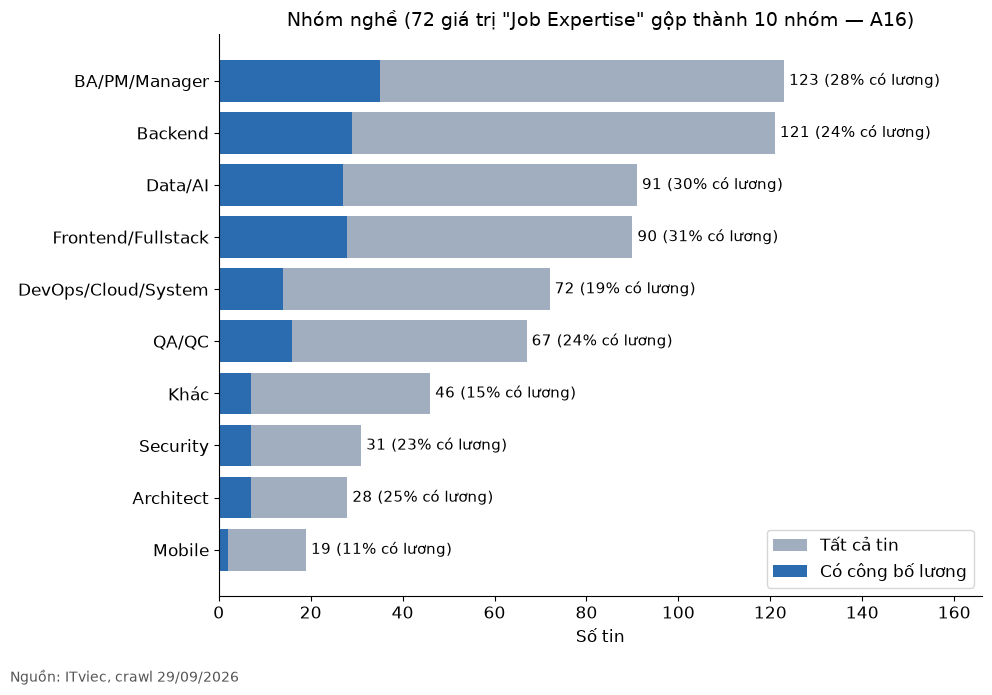

In [17]:
fig = FIGURES["expertise_groups"](jobs, skills)
save_figure(fig, "expertise_groups")  # → reports/figures/eda_expertise_groups.png

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_skills_by_group.png')

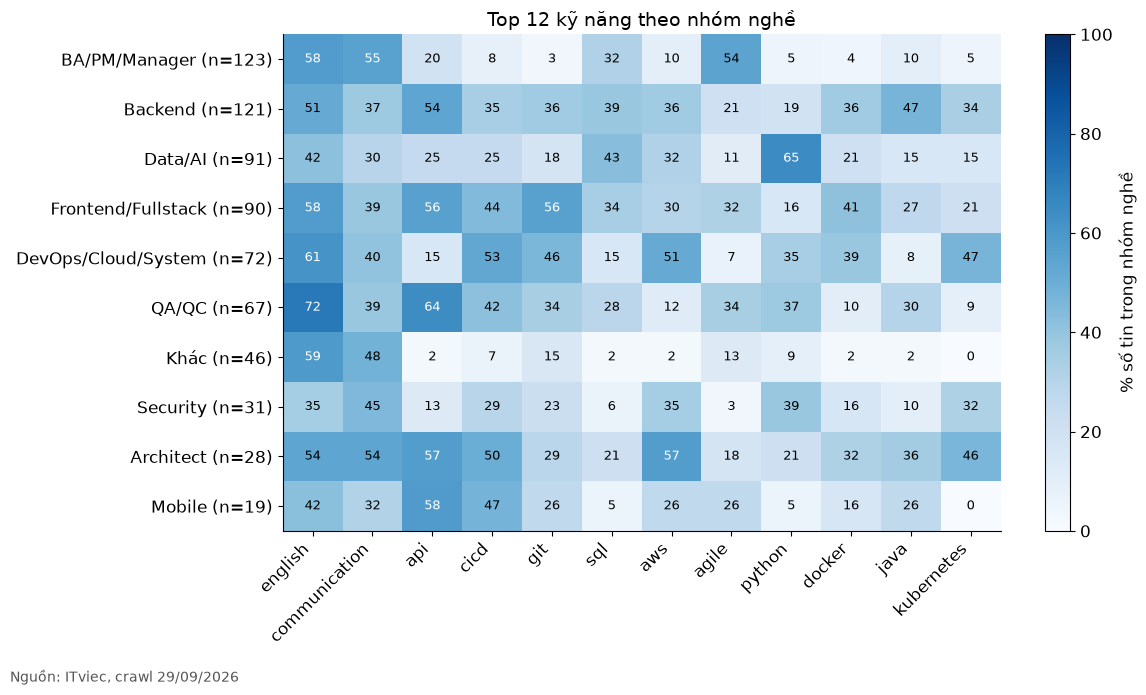

In [18]:
fig = FIGURES["skills_by_group"](jobs, skills)
save_figure(fig, "skills_by_group")  # → reports/figures/eda_skills_by_group.png

## 7. Thời điểm đăng tin

Dữ liệu là snapshot các tin **còn tuyển** ngày 29/09, nên tin cũ ít (đã hết hạn). Mốc 70%/30% là ranh giới train/test của Apriori.

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_timeline.png')

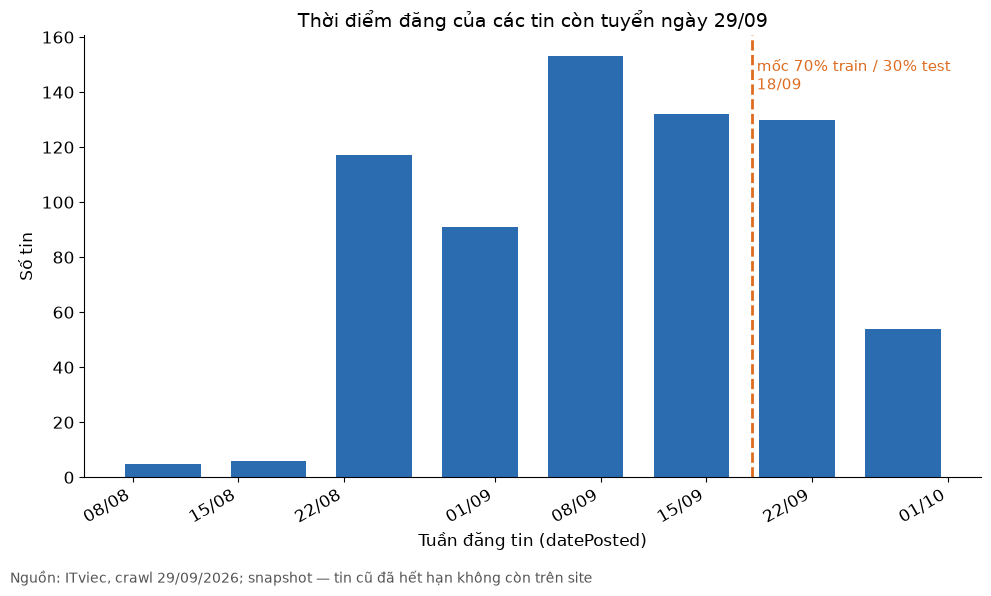

In [19]:
fig = FIGURES["timeline"](jobs, skills)
save_figure(fig, "timeline")  # → reports/figures/eda_timeline.png

In [20]:
print(f"posted_date: {jobs['posted_date'].min():%d/%m/%Y} → {jobs['posted_date'].max():%d/%m/%Y}")

posted_date: 10/08/2026 → 29/09/2026


In [21]:
saved = sorted((ROOT / "reports" / "figures").glob("eda_*.png"))
print(f"{len(saved)} hình EDA trong reports/figures/:")
for p in saved: print("  ", p.name)

14 hình EDA trong reports/figures/:
   eda_cooccurrence.png
   eda_currency.png
   eda_expertise_groups.png
   eda_levels.png
   eda_locations.png
   eda_pipeline_funnel.png
   eda_salary_by_level.png
   eda_salary_by_location.png
   eda_salary_disclosure.png
   eda_salary_distribution.png
   eda_skills_by_group.png
   eda_skills_per_job.png
   eda_timeline.png
   eda_top_skills.png
